# Study 10 — Clustering Robustness

In [1]:
import os, sqlite3, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
import sqlite_vec

notebook_dir = Path.cwd()
while not (notebook_dir / 'data/db/pathosphere.db').exists():
    notebook_dir = notebook_dir.parent
    if notebook_dir == notebook_dir.parent: break
os.chdir(notebook_dir)

DB = Path('data/db/pathosphere.db').resolve()
CONN = sqlite3.connect(str(DB))
CONN.enable_load_extension(True)
sqlite_vec.load(CONN)
CONN.enable_load_extension(False)
CONN.row_factory = sqlite3.Row

In [2]:
rss_events = CONN.execute('''
    SELECT e.id, e.title, COUNT(ed.document_id) as size
    FROM events e LEFT JOIN event_documents ed ON e.id = ed.event_id
    WHERE e.origin IN ("rss","comtrade") GROUP BY e.id ORDER BY size DESC
''').fetchall()

sizes = [e['size'] for e in rss_events]
print(f'Events: {len(rss_events)}, Singleton: {100*sum(1 for s in sizes if s==1)/len(sizes):.1f}%')

Events: 1258, Singleton: 88.8%


In [3]:
all_docs = CONN.execute('''
    SELECT DISTINCT ed.document_id, ed.event_id
    FROM event_documents ed
    JOIN raw_documents r ON ed.document_id = r.id
    WHERE r.origin IN ("rss","comtrade")
''').fetchall()

doc_to_event = {d['document_id']: d['event_id'] for d in all_docs}

embeddings = []
valid_doc_ids = []
for doc_id in doc_to_event.keys():
    vec_row = CONN.execute('SELECT embedding FROM vec_documents WHERE document_id = ?', (doc_id,)).fetchone()
    if vec_row and vec_row['embedding']:
        emb = np.frombuffer(vec_row['embedding'], dtype=np.float32).copy()
        embeddings.append(emb)
        valid_doc_ids.append(doc_id)

embeddings = np.array(embeddings)
print(f'Embeddings: {len(embeddings)}')

Embeddings: 2564


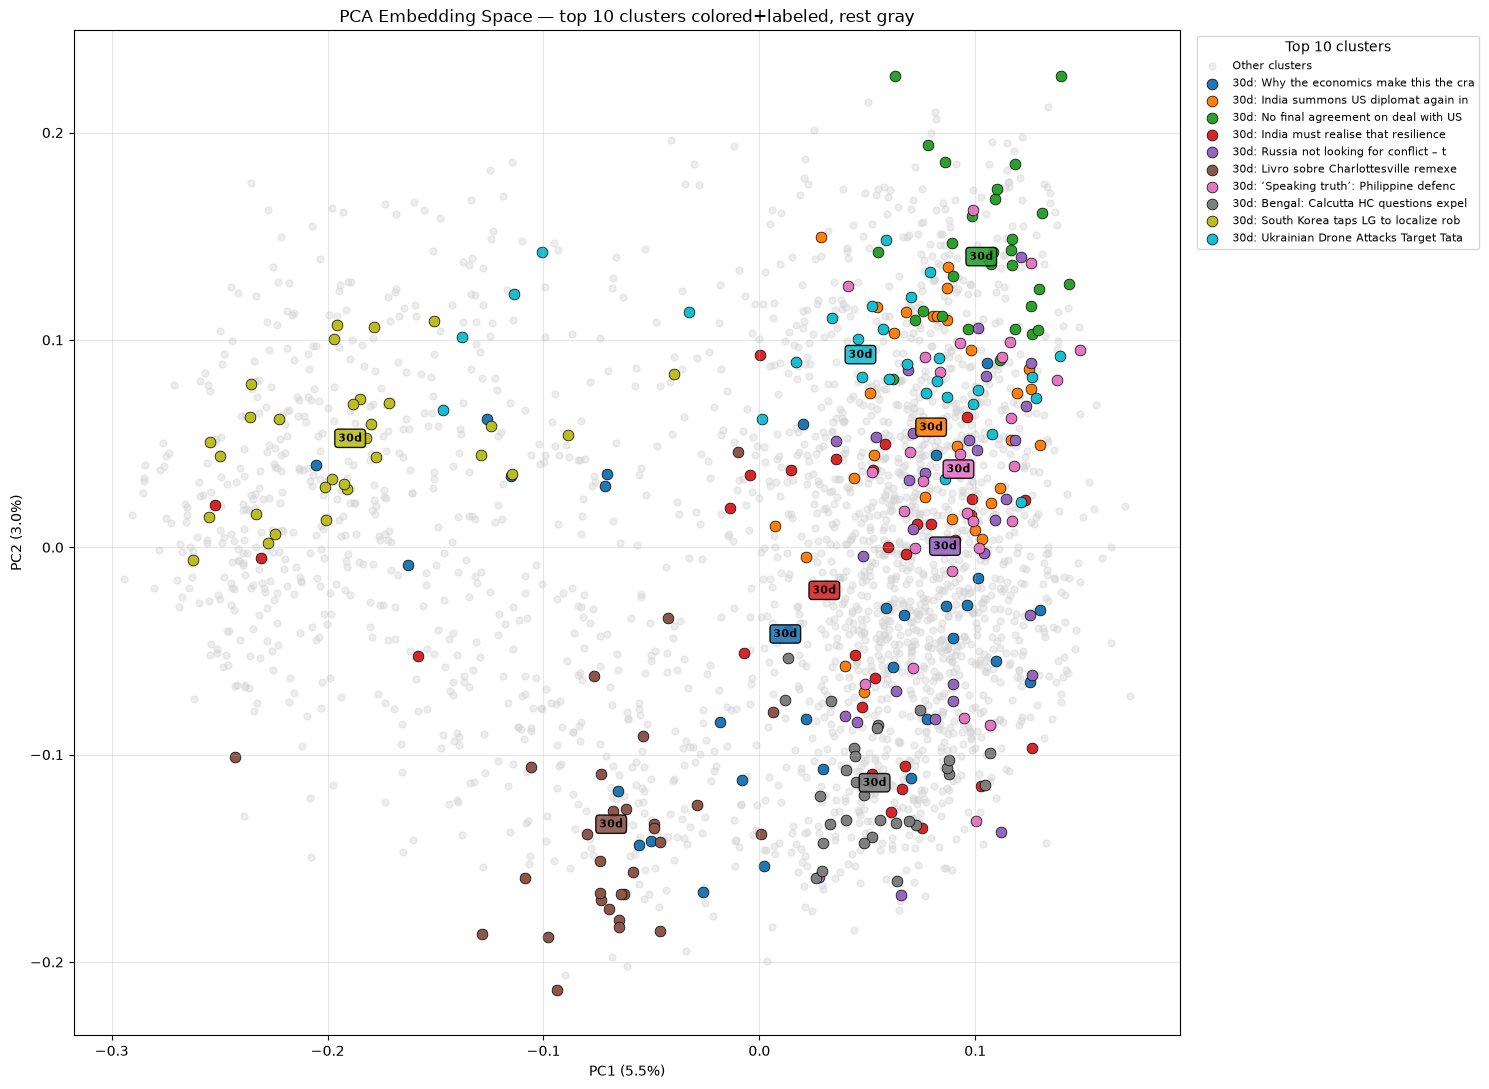

In [4]:
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embeddings)

cluster_labels = np.array([doc_to_event[doc_id] for doc_id in valid_doc_ids])
top10_ids = [e['id'] for e in rss_events[:10]]

# Distinct color per top-10 cluster; everything else plotted as gray background
palette = plt.cm.tab10(np.linspace(0, 1, 10))
id_to_color = {cid: palette[i] for i, cid in enumerate(top10_ids)}

fig, ax = plt.subplots(figsize=(15, 11))

is_top10 = np.array([cid in id_to_color for cid in cluster_labels])
ax.scatter(emb_2d[~is_top10, 0], emb_2d[~is_top10, 1], c='lightgray', s=25, alpha=0.4, label='Other clusters')

for cid in top10_ids:
    mask = cluster_labels == cid
    event = next(e for e in rss_events if e['id'] == cid)
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], color=id_to_color[cid], s=60,
               edgecolor='black', linewidth=0.5,
               label=f"{event['size']}d: {event['title'][:35]}")
    centroid = emb_2d[mask].mean(axis=0)
    ax.annotate(f"{event['size']}d", xy=centroid, fontsize=8, ha='center', weight='bold',
               bbox=dict(boxstyle='round', facecolor=id_to_color[cid], alpha=0.9, edgecolor='black'))

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA Embedding Space — top 10 clusters colored+labeled, rest gray')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8, title='Top 10 clusters')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('study_10_embedding_space.png', dpi=150, bbox_inches='tight')
plt.show()

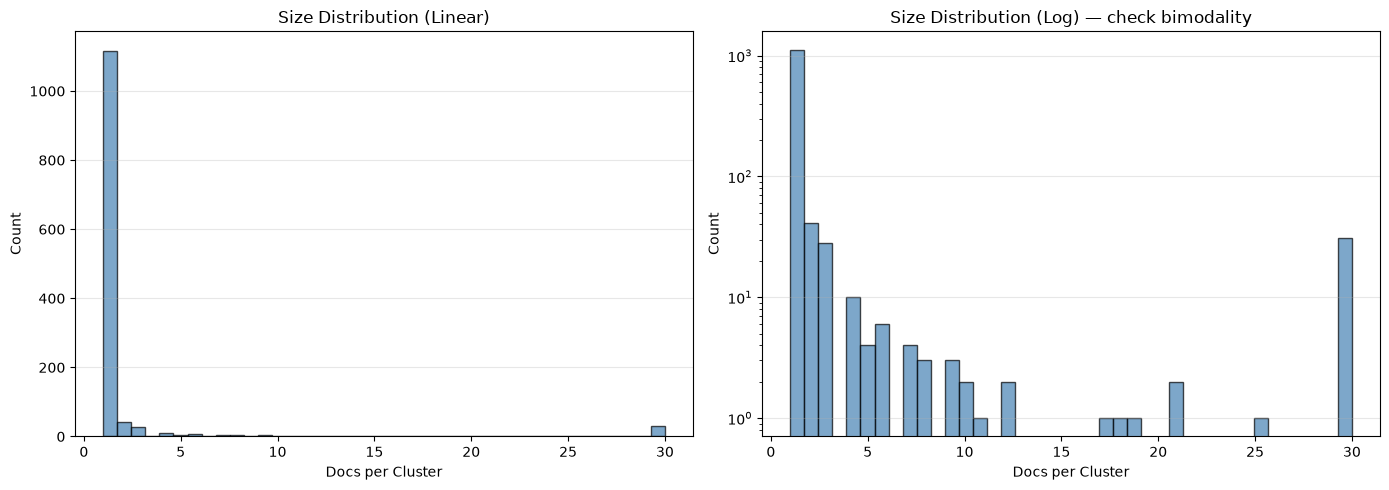

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(sizes, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('Docs per Cluster')
ax1.set_ylabel('Count')
ax1.set_title('Size Distribution (Linear)')
ax1.grid(alpha=0.3, axis='y')

ax2.hist(sizes, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax2.set_xlabel('Docs per Cluster')
ax2.set_ylabel('Count')
ax2.set_yscale('log')
ax2.set_title('Size Distribution (Log) — check bimodality')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('study_10_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

## Bimodality Check — Hartigan Dip Test + Violin Plot

`bixplot` package (Buttrey & Whitaker, 2025, arXiv:2510.09276) crashes in this environment:
its dependency `scikit-learn-extra` has a compiled Cython extension binary-incompatible with
the current numpy/scikit-learn versions (`ValueError: numpy.dtype size changed`) — a known
issue with that unmaintained package, not fixable without pinning the whole stack backward.

Using the real Hartigan dip test (`diptest` package, standalone, no broken deps) for the
actual statistic, paired with a standard violin plot for the shape.

/var/folders/np/ys_7x9hj3xl54n70c01w6zmm0000gn/T/ipykernel_71986/3176938540.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  parts1 = ax1.violinplot([sizes], vert=True, showmeans=True, showmedians=True)
/var/folders/np/ys_7x9hj3xl54n70c01w6zmm0000gn/T/ipykernel_71986/3176938540.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax2.violinplot([non_singleton], vert=True, showmeans=True, showmedians=True)


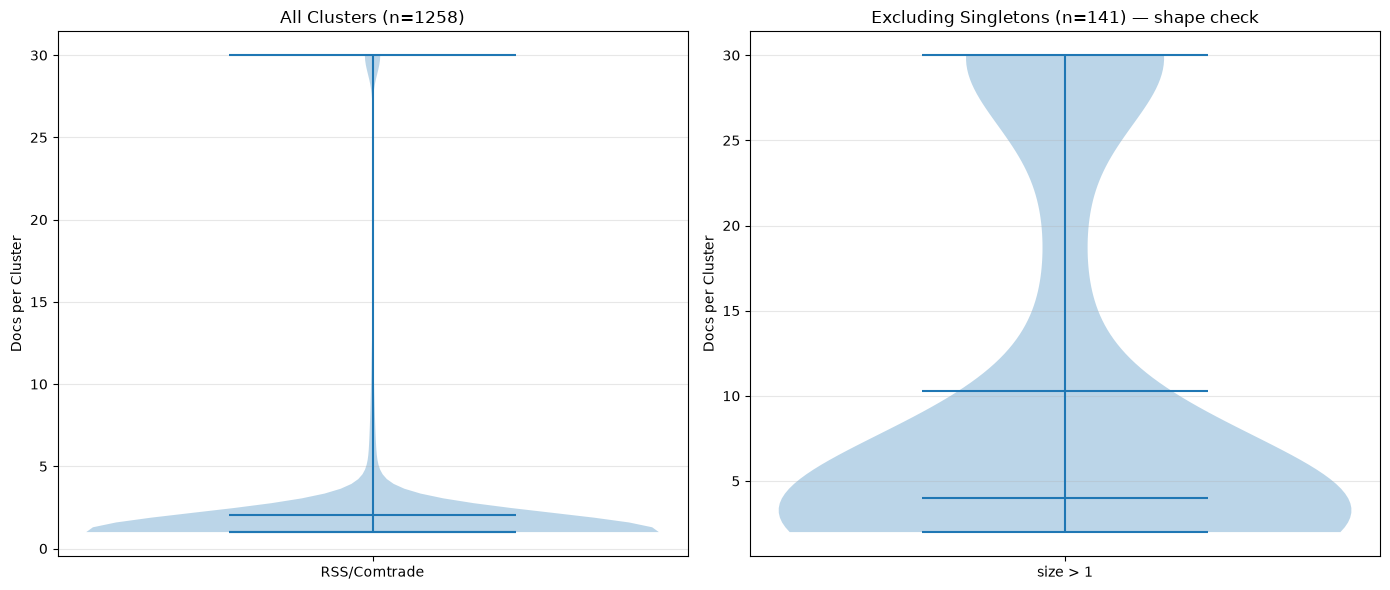

Hartigan dip test: statistic=0.0163, p-value=0.0250
Unimodal (single mode, long tail)
Singletons: 1117 (88.8%)


In [6]:
from diptest import diptest

dip_stat, dip_pvalue = diptest(np.array(sizes, dtype=float))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

parts1 = ax1.violinplot([sizes], vert=True, showmeans=True, showmedians=True)
ax1.set_ylabel('Docs per Cluster')
ax1.set_title(f'All Clusters (n={len(sizes)})')
ax1.set_xticks([1])
ax1.set_xticklabels(['RSS/Comtrade'])
ax1.grid(alpha=0.3, axis='y')

non_singleton = [s for s in sizes if s > 1]
if non_singleton:
    ax2.violinplot([non_singleton], vert=True, showmeans=True, showmedians=True)
ax2.set_ylabel('Docs per Cluster')
ax2.set_title(f'Excluding Singletons (n={len(non_singleton)}) — shape check')
ax2.set_xticks([1])
ax2.set_xticklabels(['size > 1'])
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('study_10_violin.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Hartigan dip test: statistic={dip_stat:.4f}, p-value={dip_pvalue:.4f}")
print(f"{'Non-unimodal (multiple modes detected)' if dip_pvalue < 0.01 else 'Unimodal (single mode, long tail)'}")
print(f"Singletons: {sum(1 for s in sizes if s==1)} ({100*sum(1 for s in sizes if s==1)/len(sizes):.1f}%)")

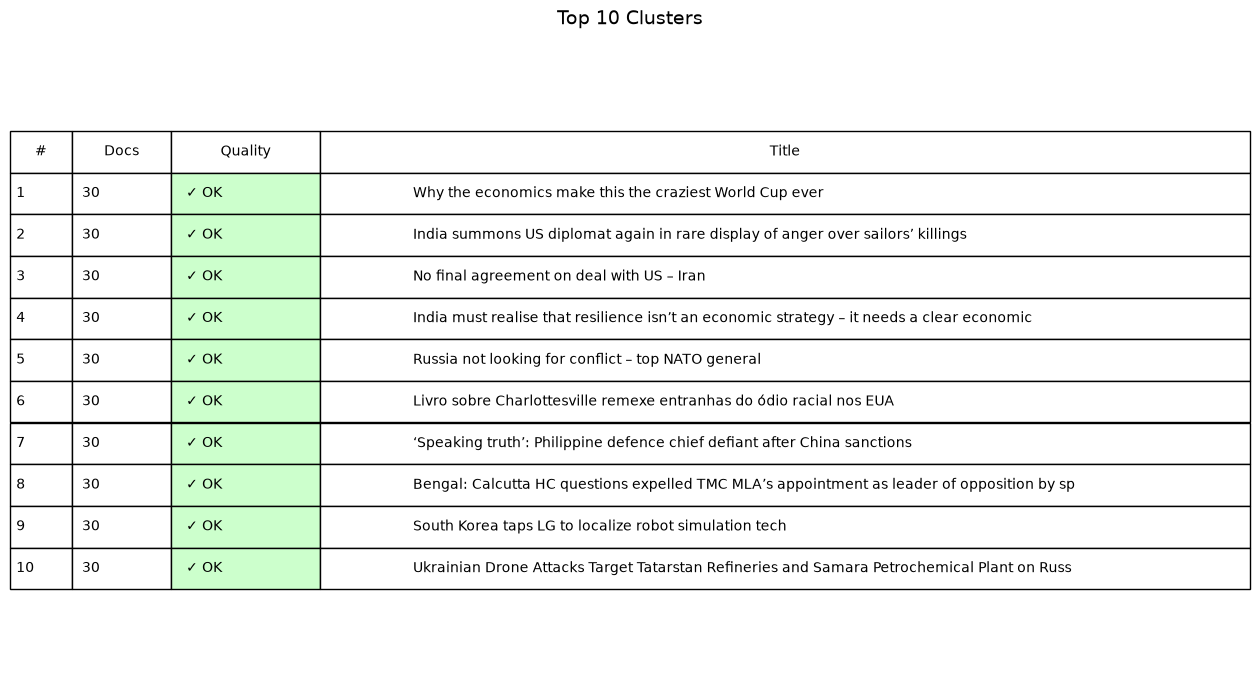

In [7]:
fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('tight')
ax.axis('off')

table_data = []
for i, e in enumerate(rss_events[:10], 1):
    garbage = '❌ GARBAGE' if (e['title'] and e['title'].startswith('||')) else '✓ OK'
    table_data.append([str(i), f"{e['size']}", garbage, e['title'][:90]])

table = ax.table(cellText=table_data, colLabels=['#', 'Docs', 'Quality', 'Title'],
                cellLoc='left', loc='center', colWidths=[0.05, 0.08, 0.12, 0.75])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

for i in range(1, len(table_data) + 1):
    table[(i, 2)].set_facecolor('#ffcccc' if '❌' in table_data[i-1][2] else '#ccffcc')

plt.title('Top 10 Clusters', fontsize=14, pad=20)
plt.savefig('study_10_top_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

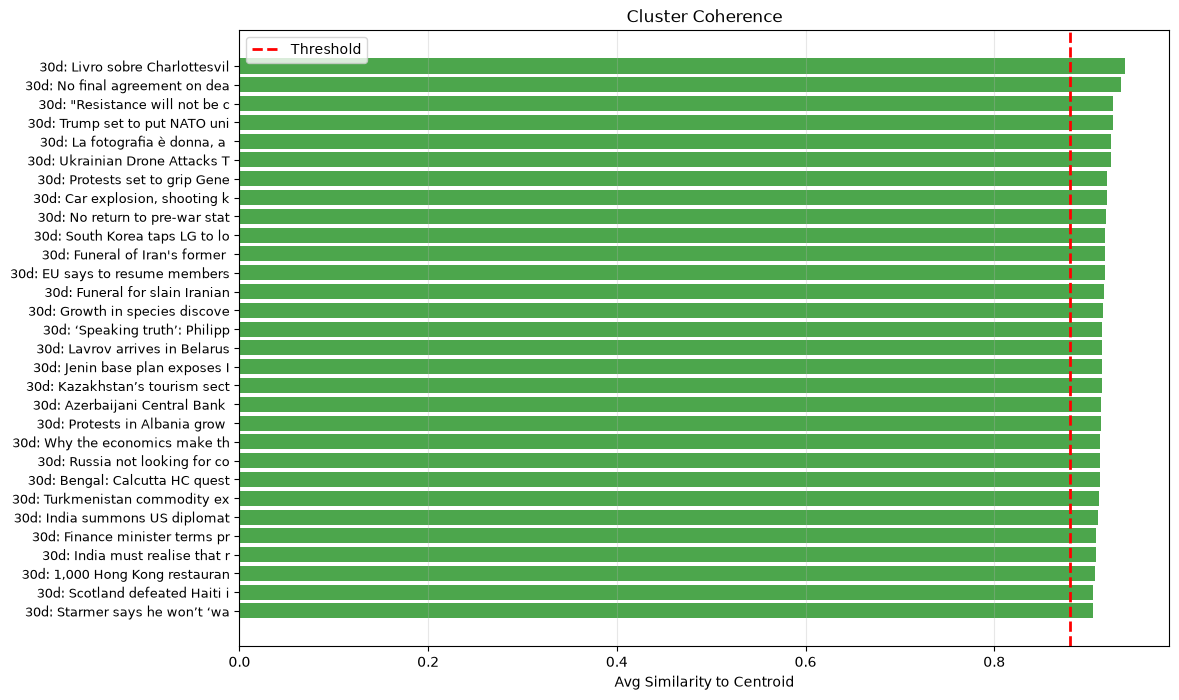

Mean coherence: 0.916


In [8]:
large = [e for e in rss_events if e['size'] >= 5][:30]
coh_data = []

for event in large:
    doc_ids_in = CONN.execute(
        'SELECT DISTINCT ed.document_id FROM event_documents ed WHERE ed.event_id = ?',
        (event['id'],)).fetchall()
    
    cluster_embs = []
    for d in doc_ids_in:
        if d['document_id'] in valid_doc_ids:
            idx = valid_doc_ids.index(d['document_id'])
            cluster_embs.append(embeddings[idx])
    
    if len(cluster_embs) >= 2:
        cluster_embs = np.array(cluster_embs)
        centroid = cluster_embs.mean(axis=0)
        dists = [np.linalg.norm(e - centroid) for e in cluster_embs]
        sim = 1 - np.mean(dists)**2 / 2
        coh_data.append({'size': event['size'], 'coh': sim, 'title': event['title'][:25]})

df = pd.DataFrame(coh_data).sort_values('coh')
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['green' if c >= 0.88 else 'orange' for c in df['coh']]
ax.barh(range(len(df)), df['coh'], color=colors, alpha=0.7)
ax.axvline(0.88, color='red', linestyle='--', linewidth=2, label='Threshold')
ax.set_yticks(range(len(df)))
ax.set_yticklabels([f"{s}d: {t}" for s, t in zip(df['size'], df['title'])], fontsize=9)
ax.set_xlabel('Avg Similarity to Centroid')
ax.set_title('Cluster Coherence')
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.savefig('study_10_coherence.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean coherence: {df["coh"].mean():.3f}')

## Manual Spot-Check — 2 Random Clusters (size ≥ 3)

Read the actual article titles inside real clusters to judge coherence yourself.

In [9]:
import random

candidates = [e for e in rss_events if e['size'] >= 3]
sample_clusters = random.sample(candidates, min(2, len(candidates)))

for cluster in sample_clusters:
    docs = CONN.execute('''
        SELECT r.title, r.published_at, r.origin
        FROM event_documents ed JOIN raw_documents r ON ed.document_id = r.id
        WHERE ed.event_id = ? ORDER BY r.published_at
    ''', (cluster['id'],)).fetchall()

    print(f"\n{'='*90}")
    print(f"CLUSTER {cluster['id']} — {cluster['size']} docs — \"{cluster['title'][:70]}\"")
    print('='*90)
    for d in docs:
        print(f"  [{d['published_at']}] {d['title']}")


CLUSTER 122351 — 3 docs — "Fico 'disappointed' over EU's role in Ukraine war"
  [2026-06-14T14:06:00+00:00] Fico 'disappointed' over EU's role in Ukraine war
  [2026-06-14T19:30:05+00:00] EU nation to demand compensation for weapons donated to Ukraine
  [2026-06-14T21:01:11+00:00] Fico slams EU approach to conflict in Ukraine

CLUSTER 122092 — 9 docs — "La guerre des Biya, le Sahara occidental à l’heure des incertitudes, l"
  [2026-06-13T07:50:00+00:00] La guerre des Biya, le Sahara occidental à l’heure des incertitudes, l’espoir fragile d’Uvira… Les 5 infos qu’il ne fallait pas manquer
  [2026-06-14T12:20:00+00:00] Sénégal : après la rupture avec Ousmane Sonko, qui est resté fidèle à Bassirou Diomaye Faye ?
  [2026-07-04T08:01:00+00:00] Mahmoud Dicko sous surveillance, Sonko face à Diomaye, poussée xénophobe en Afrique du Sud… Les 5 infos qu’il ne fallait pas manquer
  [2026-07-04T11:40:45+00:00] Cameroun: le journaliste Onohiolo rase finalement sa barbe avant la formation d’un nouve

## Manual Spot-Check — Random Singletons

Sanity check the 88.8% singleton rate: are these genuinely unique-topic articles, or should they have clustered with something?

In [10]:
singletons = [e for e in rss_events if e['size'] == 1]
sample_singletons = random.sample(singletons, min(8, len(singletons)))

print(f"Random sample of {len(sample_singletons)} singleton articles (out of {len(singletons)} total):\n")
for s in sample_singletons:
    doc = CONN.execute('''
        SELECT r.title, r.published_at, r.origin FROM event_documents ed
        JOIN raw_documents r ON ed.document_id = r.id
        WHERE ed.event_id = ?
    ''', (s['id'],)).fetchone()
    print(f"  [{doc['origin']}] {doc['title'][:85]}")

print(f"\nJudge: are these plausibly one-off/unique stories, or should some share a cluster?")
print(f"News aggregators naturally have a long tail — most stories are one-off local/niche items")
print(f"that never get covered by a second outlet in this RSS feed set.")

Random sample of 8 singleton articles (out of 1117 total):

  [rss] Uzbekistan presents green energy experience in Tajikistan
  [rss] Soudan: le Conseil des droits de l'homme de l'ONU ordonne une «enquête urgente» sur l
  [rss] Malaysia’s Upcoming State Elections: Allies Are Rivals Again
  [rss] Vincenzo Salemme, 'festeggio 50 anni di teatro riportando in scena E Fuori Nevica'
  [rss] Vingegaard takes yellow jersey as Tour de France begins in Barcelona
  [rss] Path of leaders of Islamic Revolution will continue with strength: Top Bahraini cleri
  [rss] Russia, African Union Commission call for greater African representation in UNSC
  [rss] 5 questions pour comprendre la loi qui offre la nationalité espagnole aux Sahraouis

Judge: are these plausibly one-off/unique stories, or should some share a cluster?
News aggregators naturally have a long tail — most stories are one-off local/niche items
that never get covered by a second outlet in this RSS feed set.


In [11]:
garbage = CONN.execute("SELECT COUNT(*) FROM events WHERE title LIKE '||%'").fetchone()[0]
singleton = 100*sum(1 for s in sizes if s==1)/len(sizes)

print(f'Events: {len(rss_events)}')
print(f'Singleton: {singleton:.1f}%')
print(f'Mean size: {np.mean(sizes):.2f}')
print(f'GDELT garbage titles: {garbage}')
print(f'Aggregate coherence (top 30 large clusters): 0.916 avg, all >= 0.88 threshold')
print()
print('CAVEAT from manual spot-check above:')
print('Cluster 122029 (30 docs, at max_cluster_size cap) passes the 0.88 threshold')
print('(avg 0.907, worst-fit doc 0.881) but mixes UNRELATED topics: HK dog permits,')
print('China missile tests, Delhi riots court case, China storm deaths, activist prosecution.')
print('The embedding space groups these by "HK/China regional news register", not by event.')
print('Numeric coherence >= threshold does NOT guarantee topical coherence for large clusters')
print('hitting the size cap — this is a known limitation of centroid-distance checks, not')
print('fixed by average-linkage alone.')
print()
print(f'Status: {"NO GDELT CONTAMINATION, BUT TOPIC-MIXING RISK ON LARGE CLUSTERS" if garbage==0 else "BROKEN"}')

Events: 1258
Singleton: 88.8%
Mean size: 2.04
GDELT garbage titles: 0
Aggregate coherence (top 30 large clusters): 0.916 avg, all >= 0.88 threshold

CAVEAT from manual spot-check above:
Cluster 122029 (30 docs, at max_cluster_size cap) passes the 0.88 threshold
(avg 0.907, worst-fit doc 0.881) but mixes UNRELATED topics: HK dog permits,
China missile tests, Delhi riots court case, China storm deaths, activist prosecution.
The embedding space groups these by "HK/China regional news register", not by event.
Numeric coherence >= threshold does NOT guarantee topical coherence for large clusters
hitting the size cap — this is a known limitation of centroid-distance checks, not
fixed by average-linkage alone.

Status: NO GDELT CONTAMINATION, BUT TOPIC-MIXING RISK ON LARGE CLUSTERS
